<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°5

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445

In [62]:
!pip install ucimlrepo

In [63]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

# a) Exploración de datos

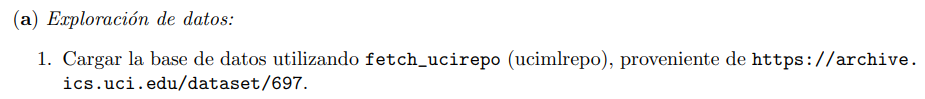

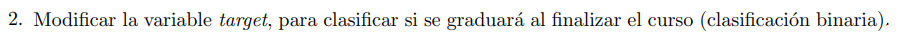

In [64]:
estudiantes = fetch_ucirepo(id = 697)

X_df = estudiantes.data.features
y_df = estudiantes.data.targets.copy()

y_df.loc[y_df['Target'] == 'Enrolled', 'Target'] = 'Dropout'


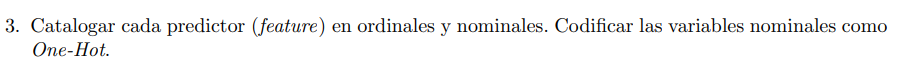

In [65]:
display(X_df.columns)
print('\n')
display(f'Hay {len(X_df.columns)} columnas')

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

'Hay 36 columnas'

In [66]:
lista_de_categoricas = ['Marital Status', 'Application mode', 'Course', 'Daytime/evening attendance',
                        'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation",
                        "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender',
                        'Scholarship holder', 'International']
print(X_df[lista_de_categoricas].shape)

print(f'Hay {len(lista_de_categoricas)} variables categóricas')

lista_de_ordinales = []

for columna in X_df.columns:
  if columna not in lista_de_categoricas:
    lista_de_ordinales.append(columna)

print(f'Hay {len(lista_de_ordinales)} variables ordinales')

(4424, 17)
Hay 17 variables categóricas
Hay 19 variables ordinales


In [67]:
ColT = sk.compose.ColumnTransformer(
    transformers = [
        ("OHE", sk.preprocessing.OneHotEncoder(sparse_output = False, drop = 'if_binary'), lista_de_categoricas)
        ],
    remainder = "passthrough" #no modifica las ordinales
)

OHE_target = sk.preprocessing.OneHotEncoder(sparse_output = False, drop = 'if_binary')

In [68]:
X_prep = ColT.fit_transform(X_df)
y_prep = OHE_target.fit_transform(y_df)

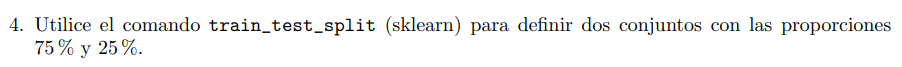

In [69]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X_prep, y_prep, test_size = 0.75)
print(f'Hay {X_train.shape[1]} features')


Hay 247 features


# b) Árbol de decisión

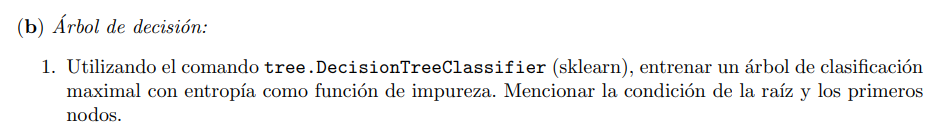

In [70]:
DTClassifier = sk.tree.DecisionTreeClassifier(criterion = 'entropy', max_depth = None)
#max_depth = None para que el árbol crezca hasta no poder más.
DTClassifier.fit(X_train, y_train)

arbol = DTClassifier.tree_
#Nota: la clase DTClassifier NO es el árbol, sino una clase con el árbol y otras cosas

In [71]:
#para ecnontrar información sobre los atributos de la clase tree
help(sk.tree._tree.Tree)

Help on class Tree in module sklearn.tree._tree:

class Tree(builtins.object)
 |  Array-based representation of a binary decision tree.
 |
 |  The binary tree is represented as a number of parallel arrays. The i-th
 |  element of each array holds information about the node `i`. Node 0 is the
 |  tree's root. You can find a detailed description of all arrays in
 |  `_tree.pxd`. NOTE: Some of the arrays only apply to either leaves or split
 |  nodes, resp. In this case the values of nodes of the other type are
 |  arbitrary!
 |
 |  Attributes
 |  ----------
 |  node_count : intp_t
 |      The number of nodes (internal nodes + leaves) in the tree.
 |
 |  capacity : intp_t
 |      The current capacity (i.e., size) of the arrays, which is at least as
 |      great as `node_count`.
 |
 |  max_depth : intp_t
 |      The depth of the tree, i.e. the maximum depth of its leaves.
 |
 |  children_left : array of intp_t, shape [node_count]
 |      children_left[i] holds the node id of the left chil

In [72]:
print(f'En el arbol hay {arbol.node_count} nodos\n') #Nota: los nodos son ramificaciones. Las hojas son decisiones finales
#cada nodo está identificado por un id

print(f'En el nodo de la raíz se usa la feature {arbol.feature[0]} y el umbral {arbol.threshold[0]}.\nSi feature > umbral, sigue por la derecha. Si feature es <= umbral, sigue por la izquierda\n')

id_izq = arbol.children_left[0] #id del nodo a la izquierda del nodo 0(raíz)
id_der = arbol.children_right[0]

print(f'El nodo a la izquierda de la raíz tiene id = {id_izq}')
print(f'El nodo a la derecha de la raíz tiene id = {id_der}\n')

print(f'En el nodo de la izquierda se tiene el umbral {arbol.threshold[id_izq]} para la feature {arbol.feature[id_izq]}')
print(f'En el nodo de la derecha se tiene el umbral {arbol.threshold[id_der]} para la feature {arbol.feature[id_der]}')

En el arbol hay 277 nodos

En el nodo de la raíz se usa la feature 241 y el umbral 4.5.
Si feature > umbral, sigue por la derecha. Si feature es <= umbral, sigue por la izquierda

El nodo a la izquierda de la raíz tiene id = 1
El nodo a la derecha de la raíz tiene id = 88

En el nodo de la izquierda se tiene el umbral 19.5 para la feature 231
En el nodo de la derecha se tiene el umbral 9.5 para la feature 234


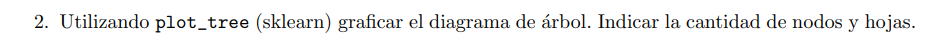

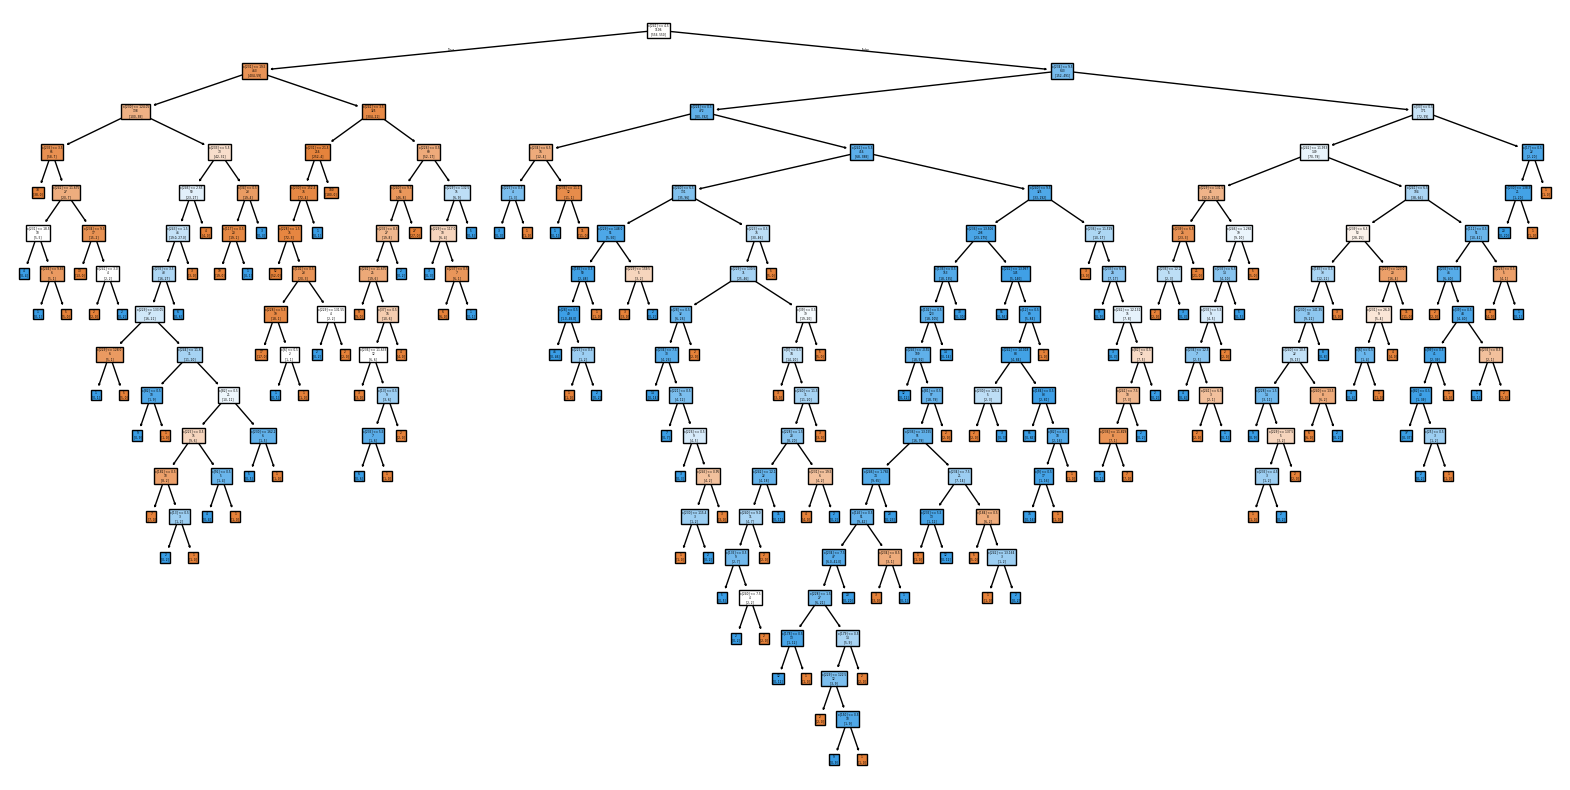

In [73]:
plt.figure(figsize = (20, 10))
sk.tree.plot_tree(DTClassifier, feature_names = None, impurity = False, label = 'none', filled = True)
plt.show()

image.png

In [74]:
#Accuracy y F1
y_pred = DTClassifier.predict(X_test) #arreglo de numpy
print(f'Accuracy: {sk.metrics.accuracy_score(y_test, y_pred)}')
print(f'F1: {sk.metrics.f1_score(y_test, y_pred, average="binary")}')

indices_ordenados = np.flip(np.argsort(arbol.compute_feature_importances(normalize = False)))#array con los indices que ordenarian el array de compute_feature_importance
#lo ordena de menor a mayor, así que uso np.flip
print(f'Las 2 features más relevantes son {indices_ordenados[0]} y {indices_ordenados[1]}')

Accuracy: 0.7839059674502713
F1: 0.7873034707801839
Las 2 features más relevantes son 241 y 234


#c) Podado

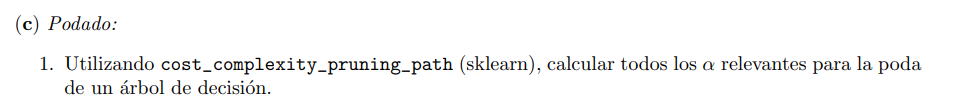

In [91]:
ccp_path = DTClassifier.cost_complexity_pruning_path(X_train, y_train)# Eso es un diccionario con los siguientes atributos:
ccp_alphas, impurities = ccp_path.ccp_alphas, ccp_path.impurities
#Estos son los alphas relevantes, es decir los alphas para los cuales la poda produce un arbol distinto
#las impuerzas son las asociadas al arbol podado con su respectivo alpha
print(ccp_alphas)
print(impurities)

print(f'Hay {len(ccp_alphas)} alphas relevantes')

[0.         0.00180832 0.00180832 0.00219473 0.00249086 0.00249086
 0.00249086 0.00249086 0.00249086 0.00249086 0.00249086 0.00260203
 0.00271248 0.00278698 0.00286076 0.0029341  0.0029341  0.0030831
 0.00318664 0.0032387  0.00326369 0.00326369 0.00326369 0.00326958
 0.00330043 0.00337682 0.00337734 0.00337972 0.00345184 0.0035139
 0.00352634 0.003609   0.00361664 0.00365081 0.00374476 0.00379765
 0.00383371 0.00387676 0.0040529  0.00412838 0.00431976 0.00432415
 0.00433749 0.0043707  0.00437113 0.00438947 0.00438947 0.00440115
 0.00441203 0.00456965 0.00458592 0.00471182 0.00476529 0.00477713
 0.00480112 0.00484807 0.00494611 0.00498994 0.00517897 0.00525033
 0.00574962 0.0062191  0.00641965 0.00642693 0.00643541 0.00651263
 0.00653896 0.00687654 0.00737021 0.00784035 0.0083203  0.00881339
 0.00936745 0.01036206 0.01082536 0.01205263 0.01210189 0.01792258
 0.02366061 0.02669142 0.31089171]
[0.         0.00180832 0.00542495 0.00981442 0.01230528 0.01479614
 0.01977785 0.02226871 0.0247

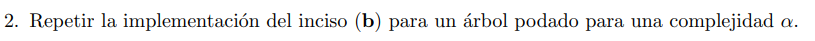

In [92]:
DTC_list = []#lista con DecisionTreeClassifiers que voy a entrenar para cada alpha

for alpha in ccp_alphas:
  DTC = sk.tree.DecisionTreeClassifier(criterion = 'entropy', max_depth = None, ccp_alpha = alpha)
  DTC.fit(X_train, y_train)
  DTC_list.append(DTC)

Alpha: 0.0
En el nodo de la raíz se usa la feature 241 y el umbral 4.5

En el nodo de la izquierda se tiene el umbral 19.5 para la feature 231
En el nodo de la derecha se tiene el umbral 9.5 para la feature 234
Accuracy: 0.7811934900542495
F1: 0.7807971014492754
Las 2 features más relevantes son 241 y 234


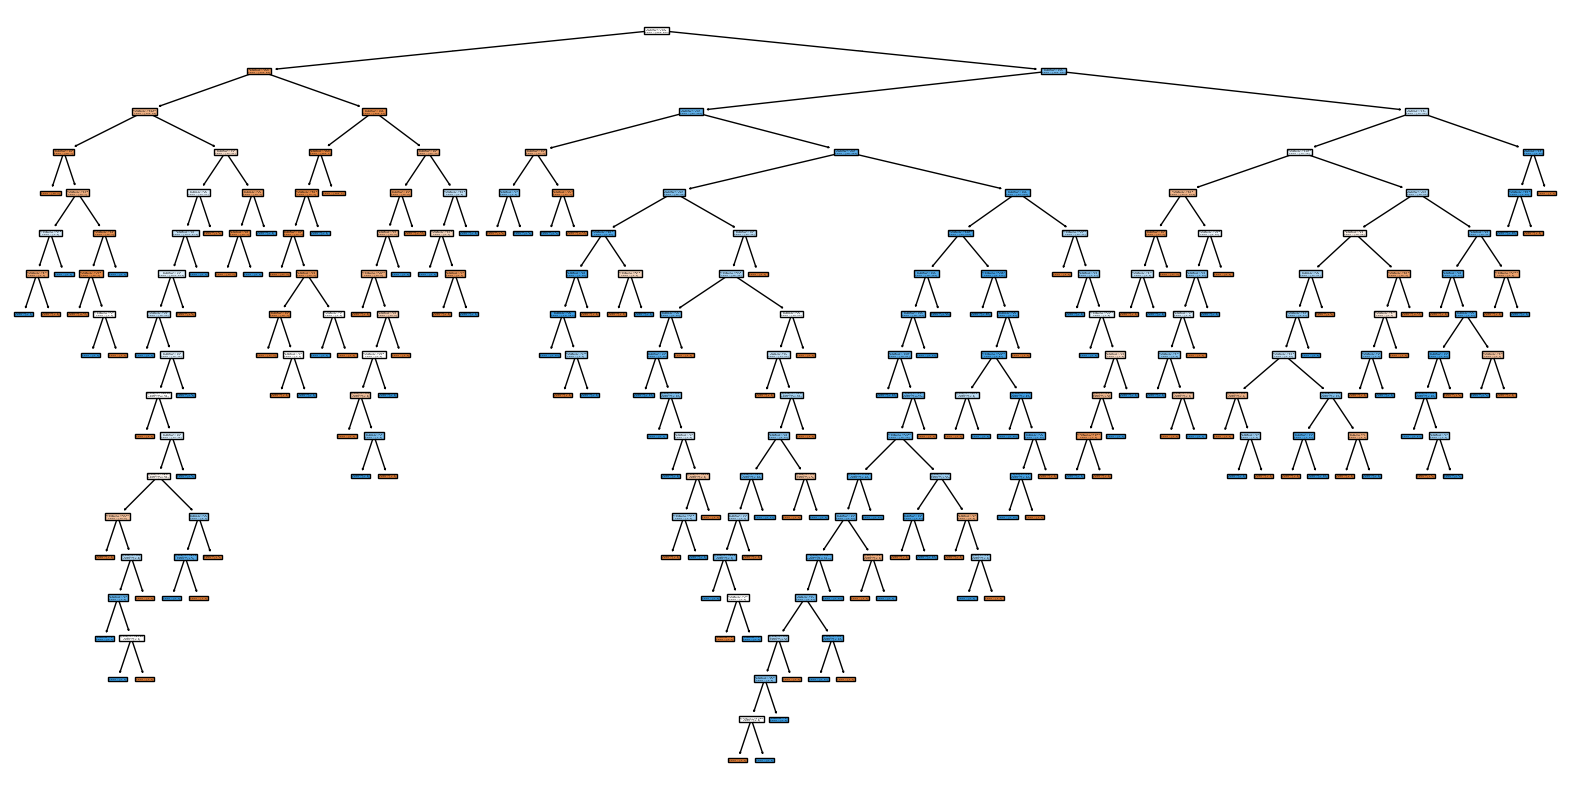

Alpha: 0.0035263422512568938
En el nodo de la raíz se usa la feature 241 y el umbral 4.5

En el nodo de la izquierda se tiene el umbral 19.5 para la feature 231
En el nodo de la derecha se tiene el umbral 9.5 para la feature 234
Accuracy: 0.7757685352622061
F1: 0.7794902193242442
Las 2 features más relevantes son 241 y 234


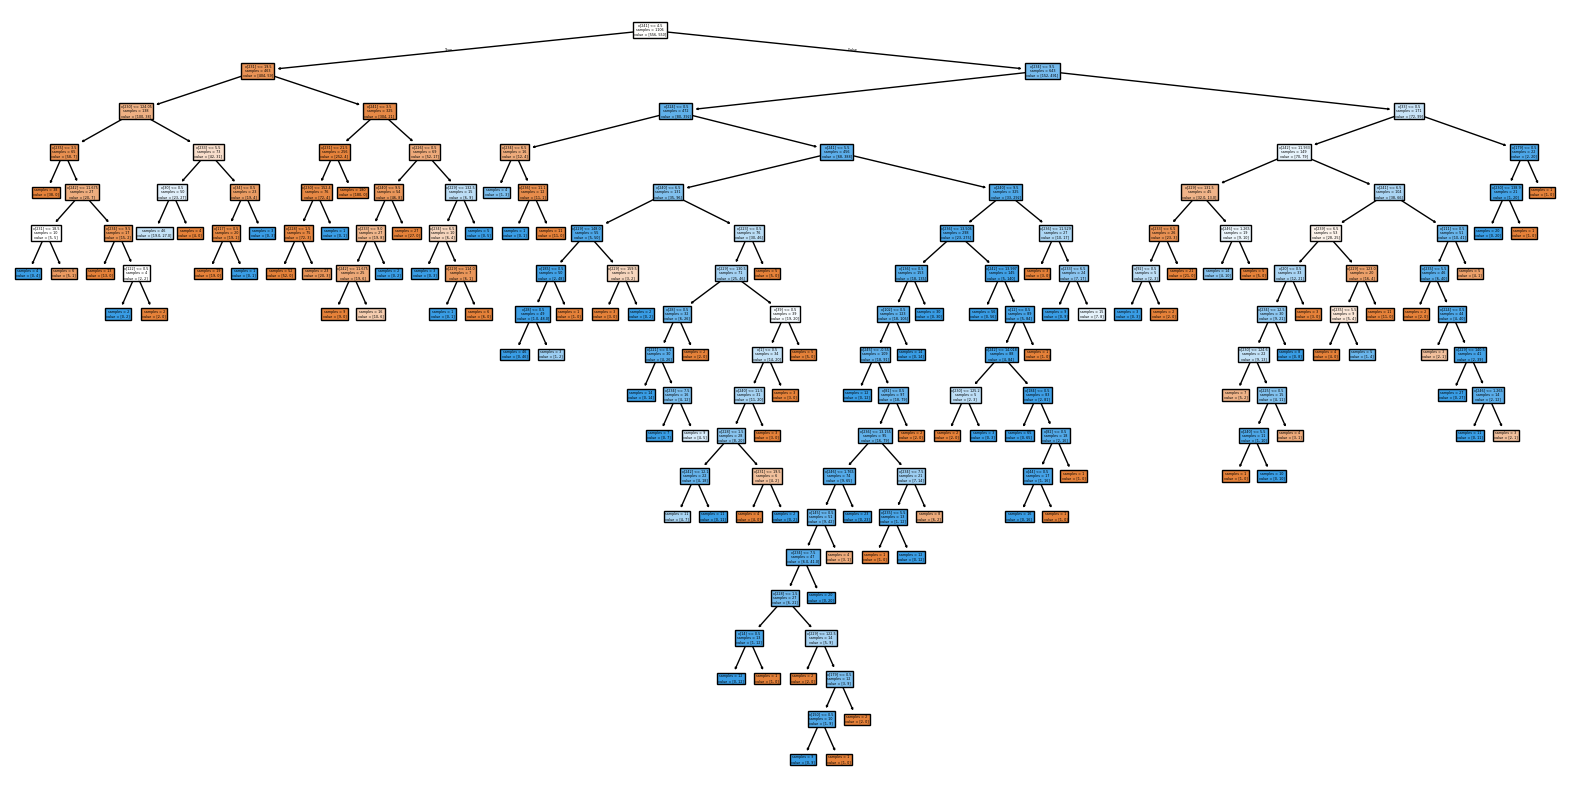

Alpha: 0.00832030060213354
En el nodo de la raíz se usa la feature 241 y el umbral 4.5

En el nodo de la izquierda se tiene el umbral 19.5 para la feature 231
En el nodo de la derecha se tiene el umbral 9.5 para la feature 234
Accuracy: 0.8182640144665461
F1: 0.8223858615611193
Las 2 features más relevantes son 241 y 234


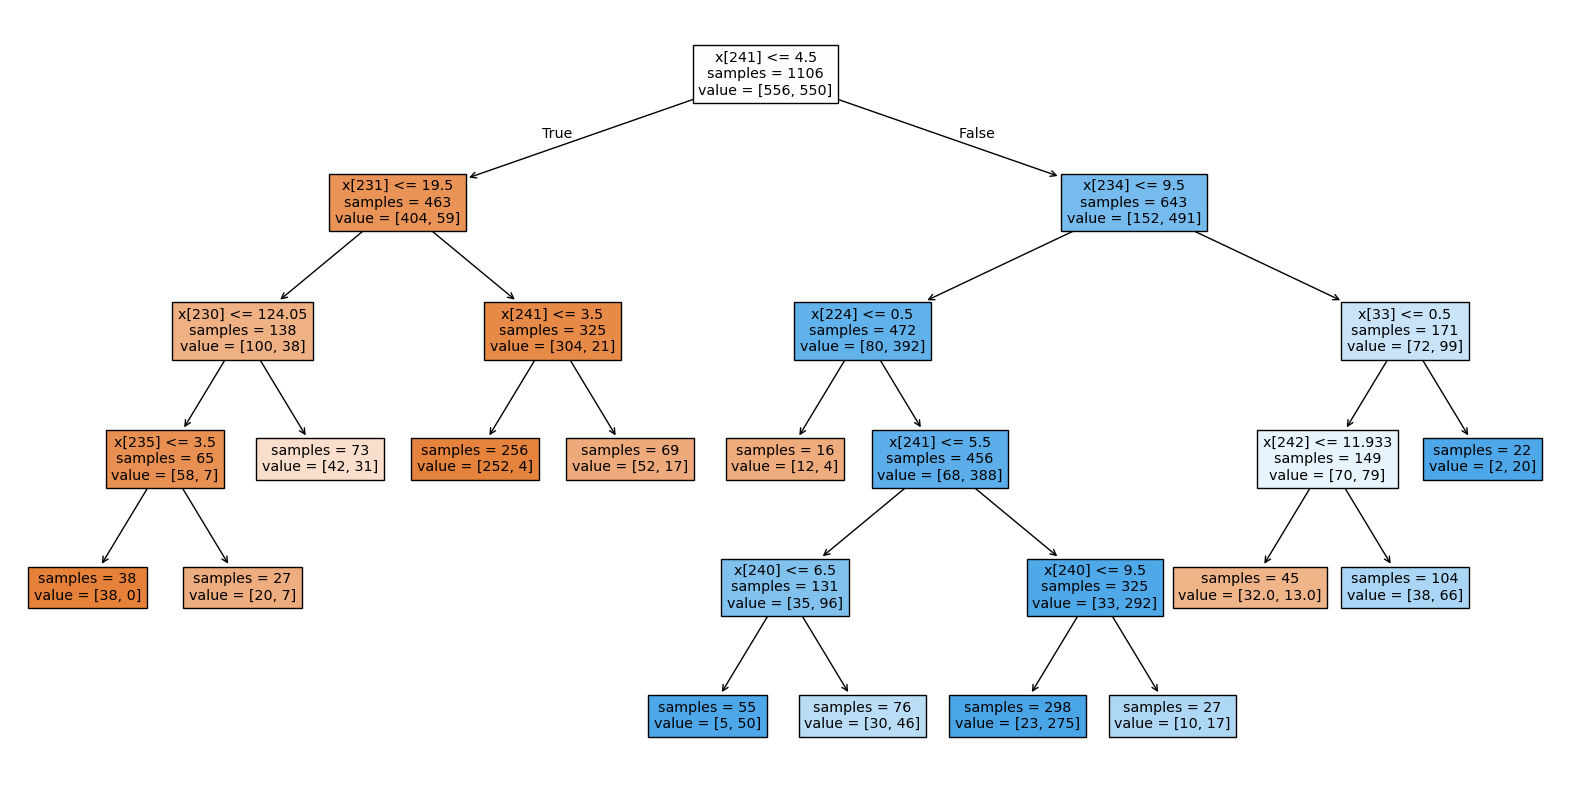

In [93]:
indices = [0, 30, 70]

for ind in indices:
  print(f'Alpha: {ccp_alphas[ind]}')
  arbol = DTC_list[ind].tree_
  print(f'En el nodo de la raíz se usa la feature {arbol.feature[0]} y el umbral {arbol.threshold[0]}\n')

  id_izq = arbol.children_left[0]
  id_der = arbol.children_right[0]

  print(f'En el nodo de la izquierda se tiene el umbral {arbol.threshold[id_izq]} para la feature {arbol.feature[id_izq]}')
  print(f'En el nodo de la derecha se tiene el umbral {arbol.threshold[id_der]} para la feature {arbol.feature[id_der]}')

  y_pred = DTC_list[ind].predict(X_test)
  print(f'Accuracy: {sk.metrics.accuracy_score(y_test, y_pred)}')
  print(f'F1: {sk.metrics.f1_score(y_test, y_pred, average="binary")}')

  indices_ordenados = np.flip(np.argsort(arbol.compute_feature_importances(normalize = False)))
  print(f'Las 2 features más relevantes son {indices_ordenados[0]} y {indices_ordenados[1]}')

  plt.figure(figsize = (20, 10))
  sk.tree.plot_tree(DTC_list[ind], feature_names = None, impurity = False, filled = True)
  plt.show()

Observación: La F1 mejora para árboles más chicos.

Todos los árboles usan la misma condición en la raíz y en los primeros nodos

Todos los árboles coinciden en cuál es la feature más importante

Conclusión: Un árbol sin podar está sobreajustado

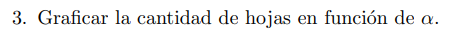

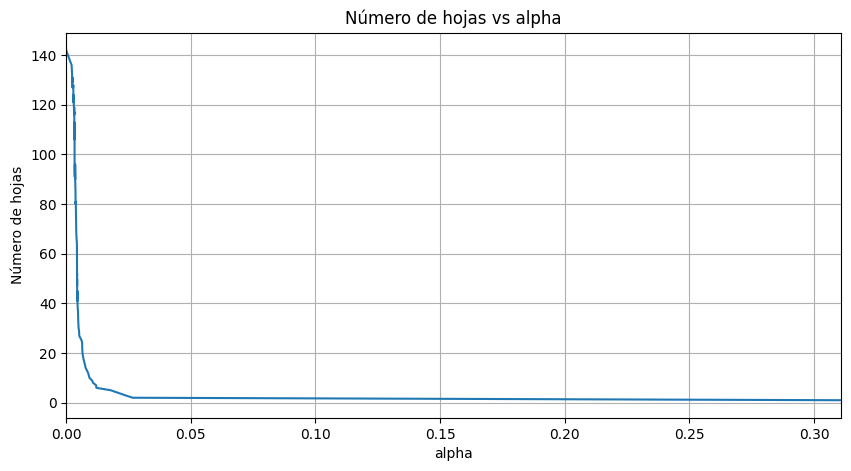

In [94]:
n_hojas = []

for DTC in DTC_list:
  arbol = DTC.tree_
  n_hojas.append(arbol.n_leaves)


plt.figure(figsize = (10, 5))
plt.plot(ccp_alphas, n_hojas)

plt.xlim(0, ccp_alphas[-1])

plt.grid(True)
plt.title('Número de hojas vs alpha')
plt.xlabel('alpha')
plt.ylabel('Número de hojas')
plt.show()

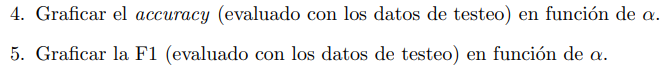

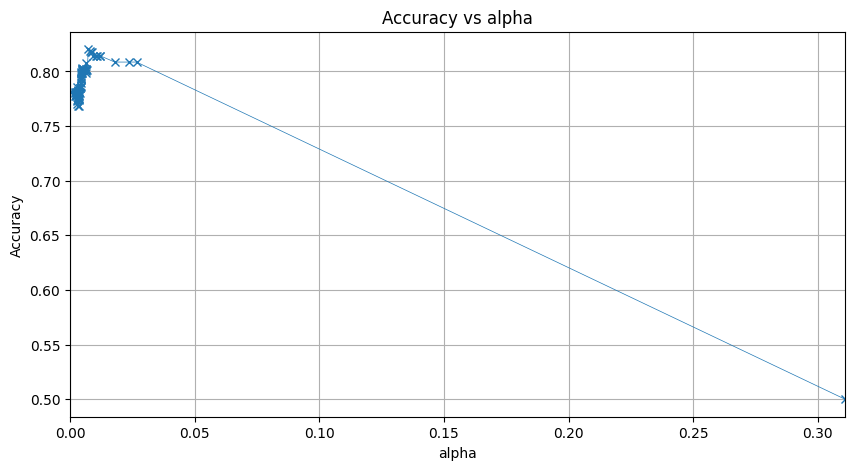

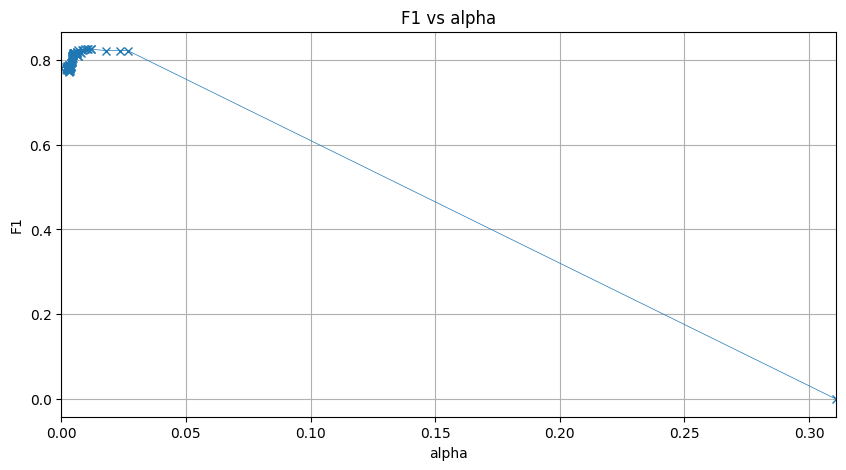

In [98]:
#accuracy y F1 en función de alpha

accuracy_list = []
f1_list = []

for DTC in DTC_list:
  y_pred = DTC.predict(X_test)
  accuracy_list.append(sk.metrics.accuracy_score(y_test, y_pred))
  f1_list.append(sk.metrics.f1_score(y_test, y_pred))

plt.figure(figsize = (10, 5))
plt.plot(ccp_alphas, accuracy_list, lw = 0.5, marker = 'x')

plt.xlim(0, ccp_alphas[-1])

plt.grid(True)
plt.title('Accuracy vs alpha')
plt.xlabel('alpha')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize = (10, 5))
plt.plot(ccp_alphas, f1_list, lw = 0.5, marker = 'x')

plt.xlim(0, ccp_alphas[-1])

plt.grid(True)
plt.title('F1 vs alpha')
plt.xlabel('alpha')
plt.ylabel('F1')
plt.show()





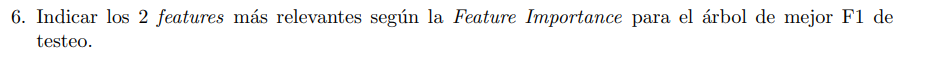

In [99]:
mejor_F1_indice = np.argmax(f1_list)
mejor_arbol = DTC_list[mejor_F1_indice].tree_

indices_ordenados = np.flip(np.argsort(mejor_arbol.compute_feature_importances()))
print(f'Las 2 features más relevantes para el árbol con mejor F1 son {indices_ordenados[0]} y {indices_ordenados[1]}\n')
print(f'Para ese árbol, la F1 es {f1_list[mejor_F1_indice]}')


Las 2 features más relevantes para el árbol con mejor F1 son 241 y 234

Para ese árbol, la F1 es 0.8248009101251422


Observación: La última marca representa el árbol con una sola hoja.

Conclusión: Podar los árboles tiende a aumentar la F1, pero solo hasta cierto punto.

# d) Bosque aleatorio

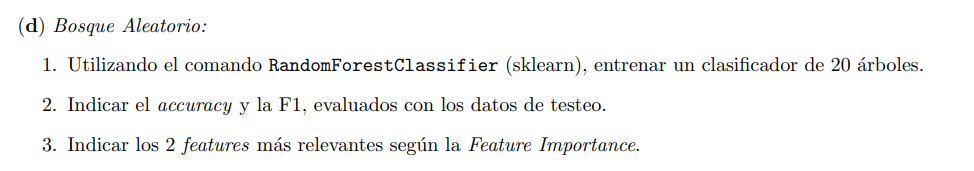

In [81]:
RFC = sk.ensemble.RandomForestClassifier(n_estimators = 20, criterion = 'entropy', max_depth = None)
RFC.fit(X_train, y_train.flatten())
y_predict = RFC.predict(X_test)

print(f'Accuracy: {sk.metrics.accuracy_score(y_test, y_predict)}')
print(f'F1: {sk.metrics.f1_score(y_test, y_predict)}')

Accuracy: 0.8215792646172393
F1: 0.8214716525934861


In [82]:
indices_ordenados = np.flip(np.argsort(RFC.feature_importances_))
print(f'Las 2 features más relevantes para el bosque son {indices_ordenados[0]} y {indices_ordenados[1]}')

Las 2 features más relevantes para el bosque son 241 y 235


Observación: La F1 del bosque es similar a la F1 del árbol con mejor F1

También coinciden en la importancia de las features

Concluisón: Entrenar un bosque tiene efectos similares a entrenar un árbol con el alfa óptimo